## **Prompt-based Image Generation using Diffusion Models for Data Augmentation (with Flux)**

*N. Bacherotti, L. Ceccarelli, M. Meazzini*

### Setup and Global Configuration

In [1]:
from pathlib import Path
import copy
import gc
import json
import math
import os
import random
import sys
import time
import re

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from scipy.stats import binomtest

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from diffusers import DiffusionPipeline
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
import seaborn as sns
from sklearn.calibration import CalibrationDisplay
from torch.utils.data import ConcatDataset, DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet18
from torchvision.utils import save_image
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BlipForConditionalGeneration,
    BlipProcessor,
)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name != "seai_project":
    PROJECT_DIR = PROJECT_DIR / "seai_project"

BASE_DIR = PROJECT_DIR / "dataset"
DATA_ROOT = BASE_DIR / "oxford_pets"
SPLITS_DIR = BASE_DIR / "splits"

TEST_MODE = True         
RUN_GENERATION = True   
RUN_EXP_1 = True
MODEL_NAME = "flux" 
N_FOLDS = 5

if TEST_MODE:
    N_MAJORITY_TRAIN = 100
    N_MINORITY_TRAIN = 20
    NUM_EPOCHS = 3
    PATIENCE = 3
    RUN_TAG = "TEST"
else:
    N_MAJORITY_TRAIN = 4000
    N_MINORITY_TRAIN = 400
    NUM_EPOCHS = 50
    PATIENCE = 10
    RUN_TAG = "FULL"

SPLIT_PATH = SPLITS_DIR / f"split_indices_{RUN_TAG}_seed43.npz"
CV_FOLDS_PATH = SPLITS_DIR / f"cv_folds_{RUN_TAG}_seed43.npz"

K_FOLD_OUTPUT_DIR = BASE_DIR / "k_fold_outputs" / f"{MODEL_NAME}_{RUN_TAG}"
K_FOLD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSIC_AUG_DIR = BASE_DIR / f"classic_augmented_baseline_{RUN_TAG}"
BASELINE_CV_DIR = K_FOLD_OUTPUT_DIR / "baseline_classic_balanced"



JSON_PATH = BASE_DIR / "captions" / f"blip_qwen_captions_{MODEL_NAME}_{RUN_TAG}.json"
FLUX_IN_DIR = BASE_DIR / f"{MODEL_NAME}_inputs_{RUN_TAG}"
FLUX_OUT_DIR = BASE_DIR / f"{MODEL_NAME}_outputs_{RUN_TAG}" / "edited"

if RUN_GENERATION:
    FLUX_OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = BASE_DIR / f"classifier_outputs_{MODEL_NAME}_{RUN_TAG}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model Name: {MODEL_NAME}")
print(f"Mode: {RUN_TAG}")
print(f"Generation Enabled: {RUN_GENERATION}")
print(f"Epochs: {NUM_EPOCHS}")

Model Name: flux
Mode: TEST
Generation Enabled: True
Epochs: 3


In [3]:
FLUX_IMG_SIZE = 1024 
IMG_SIZE = 224       
BATCH_SIZE = 32
NUM_WORKERS = 0
SEED = 42

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

class_names = ["dog", "cat"]
num_classes = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])



classic_offline_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
])



eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


### Dataset Preparation and Imbalanced Split

In [5]:
class BinaryPetWrapper(Dataset):
    """
    Takes images from Oxford Pets (37 classes) and dynamically maps them to 2 classes:
    0 -> Dog (Majority)
    1 -> Cat (Minority)
    """
    def __init__(self, concat_dataset, indices, transform=None):
        self.dataset = concat_dataset
        self.indices = list(indices)
        self.transform = transform
        
        self.cat_breeds = [
            'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair', 
            'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue', 
            'Siamese', 'Sphynx'
        ]
        
        classes = self.dataset.datasets[0].classes
        self.cat_indices = {classes.index(b) for b in self.cat_breeds}

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, original_label = self.dataset[real_idx]
        
        new_label = 1 if original_label in self.cat_indices else 0
        
        if self.transform:
            image = self.transform(image)
            
        return image, new_label

In [6]:
print("Downloading/Verifying dataset...")

base_trainval = OxfordIIITPet(root=DATA_ROOT, split="trainval", download=True)
base_test = OxfordIIITPet(root=DATA_ROOT, split="test", download=True)
full_dataset = ConcatDataset([base_trainval, base_test])

all_targets = np.concatenate([base_trainval._labels, base_test._labels])
classes = base_trainval.classes

cat_class_indices = {classes.index(b) for b in [
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian Mau", "Maine Coon", "Persian", "Ragdoll", "Russian Blue",
    "Siamese", "Sphynx"
]}
binary_targets = np.array([1 if t in cat_class_indices else 0 for t in all_targets])

if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"Split not found! Missing: {SPLIT_PATH}")

print(f"Loading existing split from {SPLIT_PATH}...")
split = np.load(SPLIT_PATH)

majority_train_idx = split["majority_train_idx"]
minority_train_idx = split["minority_train_idx"]
majority_test_idx = split["majority_test_idx"]
minority_test_idx = split["minority_test_idx"]

print("Available dogs in train:", len(majority_train_idx))
print("Available cats in train:", len(minority_train_idx))

Downloading/Verifying dataset...
Loading existing split from /workspace/seai_project/dataset/splits/split_indices_TEST_seed43.npz...
Available dogs in train: 100
Available cats in train: 20


In [7]:
train_idx = np.concatenate([majority_train_idx, minority_train_idx])
test_idx = np.concatenate([majority_test_idx, minority_test_idx])

cv_indices = train_idx.copy()
cv_labels = binary_targets[cv_indices]

train_dataset = BinaryPetWrapper(full_dataset, train_idx, transform=train_transform)
test_dataset = BinaryPetWrapper(full_dataset, test_idx, transform=eval_transform)

assert not set(train_idx) & set(test_idx)

print("Train:", np.bincount(binary_targets[train_idx]))
print("Fixed test:", np.bincount(binary_targets[test_idx]))

Train: [100  20]
Fixed test: [40 40]


In [8]:
if not CV_FOLDS_PATH.exists():
    raise FileNotFoundError(f"CV Folds not found! Missing: {CV_FOLDS_PATH}")

print(f"Loading CV folds from {CV_FOLDS_PATH}...")
cv_folds = np.load(CV_FOLDS_PATH)

all_cv_val = []
for fold in range(1, N_FOLDS + 1): # N_FOLDS = 5
    tr = cv_folds[f"train_{fold}"]
    va = cv_folds[f"val_{fold}"]
    
    assert not set(tr) & set(va)
    all_cv_val.extend(va.tolist())
    
    print(f"Fold {fold}: train {np.bincount(binary_targets[tr])} | val {np.bincount(binary_targets[va])}")

assert set(all_cv_val) == set(cv_indices.tolist())

Loading CV folds from /workspace/seai_project/dataset/splits/cv_folds_TEST_seed43.npz...
Fold 1: train [80 16] | val [20  4]
Fold 2: train [80 16] | val [20  4]
Fold 3: train [80 16] | val [20  4]
Fold 4: train [80 16] | val [20  4]
Fold 5: train [80 16] | val [20  4]


In [9]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))
print("✅ Dataset successfully loaded and artificially imbalanced!")

Train batches: 4
Test batches: 3
✅ Dataset successfully loaded and artificially imbalanced!


### Utilities Definition (Training, Metrics, and Plots)

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    """
    Run one complete epoch.

    If an optimizer is provided, the model is trained.
    Otherwise, the model is evaluated without gradient updates.
    """

    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    all_targets = []
    all_preds = []

    for images, targets in loader:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):

            logits = model(images)

            loss = criterion(logits, targets)

            if training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

    loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_preds
    )

    _, _, macro_f1, _ = precision_recall_fscore_support(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0
    )

    return {
        "loss": loss,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1
    }

In [11]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    patience,
    model_name="best_model.pth"
):
    """
    Train the model using early stopping based on validation macro-F1.

    The checkpoint with the lowest validation loss is saved
    and restored at the end of training.
    """

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_balanced_accuracy": [],
        "val_balanced_accuracy": [],
        "train_macro_f1": [],
        "val_macro_f1": []
    }

    best_state = copy.deepcopy(
        model.state_dict()
    )

    best_val_f1 = 0.0  
    best_epoch = 0
    no_improvement = 0

    for epoch in range(num_epochs):

        start = time.time()

        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            criterion
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["train_balanced_accuracy"].append(train_metrics["balanced_accuracy"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"{time.time() - start:.1f}s | "
            f"Train loss {train_metrics['loss']:.4f} | "
            f"Val loss {val_metrics['loss']:.4f} | "
            f"Train F1 {train_metrics['macro_f1']:.4f} | "
            f"Val F1 {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:

            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch + 1

            best_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                best_state,
                OUTPUT_DIR / model_name
            )

            no_improvement = 0
            print("Best model saved (F1 improved)")

        else:
            no_improvement += 1

        if no_improvement >= patience:
            print("Early stopping (No F1 improvement)")
            break

    model.load_state_dict(best_state)

    print(
        f"Best epoch: {best_epoch} | "
        f"Best val F1: {best_val_f1:.4f}"
    )

    return model, history

In [12]:
def plot_and_save_history(history, output_dir, fold):
    output_dir = Path(output_dir)
    with open(output_dir / f"history_fold_{fold}.json", "w") as f:
        json.dump(history, f, indent=4)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title(f"Fold {fold} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    
    axes[1].plot(history["train_macro_f1"], label="Train Macro F1")
    axes[1].plot(history["val_macro_f1"], label="Val Macro F1")
    axes[1].set_title(f"Fold {fold} - Macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    
    fig.tight_layout()
    fig.savefig(output_dir / f"learning_curves_fold_{fold}.png", dpi=200)
    plt.close(fig)

def plot_cv_boxplot(cv_df, title, output_dir):
    plt.figure(figsize=(8, 5))
    metrics_to_plot = ["balanced_accuracy", "macro_f1", "roc_auc", "pr_auc"]
    sns.boxplot(data=cv_df[metrics_to_plot])
    plt.title(title)
    plt.ylabel("Score")
    plt.tight_layout()
    plt.savefig(Path(output_dir) / "cv_metrics_boxplot.png", dpi=200)
    plt.close()

In [13]:
def build_model(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

In [14]:
@torch.no_grad()
def predict_dataset(model, loader):
    """
    Generate ground-truth labels, predicted labels and class probabilities
    for all samples contained in a DataLoader.
    """

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    for images, targets in loader:
        images = images.to(DEVICE)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)

        preds = probs.argmax(dim=1)

        y_true.extend(targets.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob)
    )

In [15]:
def evaluate(y_true, y_pred, y_prob, class_names, split):
    """Compute classification metrics. Minority class is label 1."""

    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    metrics = {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(len(class_names)), zero_division=0
    )

    for i, cls in enumerate(class_names):
        metrics[f"{cls}_precision"] = precision[i]
        metrics[f"{cls}_recall"] = recall[i]
        metrics[f"{cls}_f1"] = f1[i]
        metrics[f"{cls}_support"] = int(support[i])

    minority_probability = y_prob[:, 1]

    metrics["roc_auc"] = roc_auc_score(y_true, minority_probability)
    metrics["pr_auc"] = average_precision_score(y_true, minority_probability)

    print(f"\n===== {split.upper()} =====")
    print(f"Accuracy: {accuracy:.4f} | Balanced Accuracy: {balanced_accuracy:.4f} | Macro Precision: {macro_precision:.4f} | Macro Recall: {macro_recall:.4f} | Macro F1: {macro_f1:.4f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f} | PR-AUC: {metrics['pr_auc']:.4f}")

    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    return metrics



In [16]:
def fold_metrics(y, pred, prob):
    prob_cat = prob[:, 1] if np.asarray(prob).ndim == 2 else np.asarray(prob)
    _, recall, _, _ = precision_recall_fscore_support(y, pred, labels=[0, 1], zero_division=0)

    return {
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "roc_auc": roc_auc_score(y, prob_cat),
        "pr_auc": average_precision_score(y, prob_cat),
        "dog_recall": recall[0],
        "cat_recall": recall[1]
    }

In [17]:
def save_oof_artifacts(name, y_true, y_pred, y_prob, sample_idx, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    metrics = fold_metrics(y_true, y_pred, y_prob)
    pd.DataFrame([metrics]).to_csv(output_dir / "oof_metrics.csv", index=False)

    df_preds = pd.DataFrame({
        "sample_idx": sample_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "prob_cat": y_prob
    })
    df_preds.to_csv(output_dir / "oof_predictions.csv", index=False)
    
    errors_df = df_preds[df_preds["y_true"] != df_preds["y_pred"]].copy()
    errors_df["error_type"] = np.where(errors_df["y_pred"] == 1, "False Positive", "False Negative")
    errors_df.to_csv(output_dir / "oof_misclassified_samples.csv", index=False)

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{name} - Aggregated 5-Fold OOF")
    fig.tight_layout()
    fig.savefig(output_dir / "oof_confusion_matrix.png", dpi=200)
    plt.close(fig)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - 5-Fold OOF ROC")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "oof_roc_curve.png", dpi=200)
    plt.close()

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, label=f"AP = {metrics['pr_auc']:.3f}")
    plt.axhline(np.mean(y_true == 1), linestyle="--", label="Positive prevalence")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} - 5-Fold OOF Precision-Recall")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "oof_pr_curve.png", dpi=200)
    plt.close()
    
    fig, ax = plt.subplots(figsize=(6, 6))
    CalibrationDisplay.from_predictions(y_true, y_prob, n_bins=10, ax=ax, name=name)
    ax.set_title(f"{name} - Calibration Curve")
    fig.tight_layout()
    fig.savefig(output_dir / "oof_calibration_curve.png", dpi=200)
    plt.close(fig)

In [18]:
def save_test_artifacts(name, y_true, y_pred, y_prob, sample_idx, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    df_preds = pd.DataFrame({
        "sample_idx": sample_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "prob_cat": y_prob
    })
    errors_df = df_preds[df_preds["y_true"] != df_preds["y_pred"]].copy()
    errors_df["error_type"] = np.where(errors_df["y_pred"] == 1, "False Positive", "False Negative")
    errors_df.to_csv(output_dir / f"test_misclassified_{name.lower()}.csv", index=False)

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{name} - Ensemble Test Set CM")
    fig.tight_layout()
    fig.savefig(output_dir / f"test_confusion_matrix_{name.lower()}.png", dpi=200)
    plt.close(fig)
    
    optimal_bins = 10 if len(y_true) > 100 else 5
    
    fig, ax = plt.subplots(figsize=(6, 6))
    CalibrationDisplay.from_predictions(y_true, y_prob, n_bins=optimal_bins, ax=ax, name=f"{name} Ensemble")
    ax.set_title(f"{name} - Test Set Calibration Curve")
    fig.tight_layout()
    fig.savefig(output_dir / f"test_calibration_curve_{name.lower()}.png", dpi=200)
    plt.close(fig)

### Experiment 1: Baseline Training with Balanced Classical Data Augmentation

In [19]:
class ClassicAugmentedPathsDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths, self.transform = list(paths), transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 1


def get_classic_source_idx(path):
    match = re.fullmatch(r"pet_train_(\d+)_classic_\d+\.jpg", Path(path).name)
    if match is None:
        raise ValueError(f"Unexpected classic augmentation filename: {path}")
    return int(match.group(1))


def prepare_classic_augmentation():
    CLASSIC_AUG_DIR.mkdir(parents=True, exist_ok=True)

    n_majority, n_minority = len(majority_train_idx), len(minority_train_idx)
    n_needed = n_majority - n_minority
    base_variants, remainder = divmod(n_needed, n_minority)
    expected_paths = []

    for i, source_idx in enumerate(minority_train_idx.tolist()):
        raw_image, _ = full_dataset[source_idx]
        raw_image = raw_image.convert("RGB")
        n_variants = base_variants + (1 if i < remainder else 0)

        for variant in range(1, n_variants + 1):
            out_path = CLASSIC_AUG_DIR / f"pet_train_{source_idx}_classic_{variant}.jpg"
            expected_paths.append(out_path)

            if out_path.exists():
                continue

            local_seed = SEED + source_idx * 1_000 + variant
            random.seed(local_seed)
            np.random.seed(local_seed % (2**32 - 1))
            torch.manual_seed(local_seed)

            classic_offline_transform(raw_image).save(out_path, quality=95)

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    assert len(expected_paths) == n_needed
    assert {get_classic_source_idx(p) for p in expected_paths} == set(minority_train_idx.tolist())

    print(f"Classic augmentation pool: {len(expected_paths)} images | folder: {CLASSIC_AUG_DIR}")

    return sorted(expected_paths)

In [20]:
if RUN_EXP_1:
    BASELINE_CV_DIR.mkdir(parents=True, exist_ok=True)

    baseline_results = []
    baseline_oof_pred = np.full(len(cv_indices), -1)
    baseline_oof_prob = np.full(len(cv_indices), np.nan)
    cv_position = {int(idx): pos for pos, idx in enumerate(cv_indices)}

    cv_folds = np.load(CV_FOLDS_PATH)
    all_classic_paths = prepare_classic_augmentation()

    for fold in range(1, N_FOLDS + 1):
        fold_train_idx = cv_folds[f"train_{fold}"]
        fold_val_idx = cv_folds[f"val_{fold}"]

        train_counts = np.bincount(binary_targets[fold_train_idx], minlength=2)
        val_counts = np.bincount(binary_targets[fold_val_idx], minlength=2)

        train_cat_ids = set(fold_train_idx[binary_targets[fold_train_idx] == 1].tolist())
        val_cat_ids = set(fold_val_idx[binary_targets[fold_val_idx] == 1].tolist())

        fold_classic_paths = [p for p in all_classic_paths if get_classic_source_idx(p) in train_cat_ids]

        assert not any(get_classic_source_idx(p) in val_cat_ids for p in fold_classic_paths)
        assert train_counts[1] + len(fold_classic_paths) == train_counts[0], f"Fold {fold} is not balanced."

        real_train = BinaryPetWrapper(full_dataset, fold_train_idx, transform=train_transform)
        classic_train = ClassicAugmentedPathsDataset(fold_classic_paths, transform=train_transform)
        balanced_train = ConcatDataset([real_train, classic_train])
        fold_val = BinaryPetWrapper(full_dataset, fold_val_idx, transform=eval_transform)

        train_loader_fold = DataLoader(balanced_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
        val_loader_fold = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        OUTPUT_DIR = BASELINE_CV_DIR / f"fold_{fold}"
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

        model = build_model(SEED + fold)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        balanced_counts = [int(train_counts[0]), int(train_counts[1] + len(fold_classic_paths))]
        print(f"\nFold {fold}: real {train_counts.tolist()} | classic +{len(fold_classic_paths)} cats | balanced {balanced_counts} | val {val_counts.tolist()}")

        model, history = train_model(model, train_loader_fold, val_loader_fold, criterion, optimizer, NUM_EPOCHS, PATIENCE)
        plot_and_save_history(history, OUTPUT_DIR, fold)

        y, pred, prob = predict_dataset(model, val_loader_fold)
        metrics = fold_metrics(y, pred, prob)
        baseline_results.append({"fold": fold, **metrics})

        pos = np.array([cv_position[int(i)] for i in fold_val_idx])
        baseline_oof_pred[pos] = pred
        baseline_oof_prob[pos] = prob[:, 1]

        print(f"Fold {fold}: F1 {metrics['macro_f1']:.4f} | AUC {metrics['roc_auc']:.4f}")

        del model, optimizer, criterion
        gc.collect()
        torch.cuda.empty_cache()

Classic augmentation pool: 80 images | folder: /workspace/seai_project/dataset/classic_augmented_baseline_TEST

Fold 1: real [80, 16] | classic +64 cats | balanced [80, 80] | val [20, 4]
Epoch 01/3 | 1.3s | Train loss 1.4811 | Val loss 22.0527 | Train F1 0.5118 | Val F1 0.1429
Best model saved (F1 improved)
Epoch 02/3 | 1.0s | Train loss 0.8131 | Val loss 5.3210 | Train F1 0.5145 | Val F1 0.2448
Best model saved (F1 improved)
Epoch 03/3 | 1.0s | Train loss 0.6711 | Val loss 4.8704 | Train F1 0.5614 | Val F1 0.4545
Best model saved (F1 improved)
Best epoch: 3 | Best val F1: 0.4545
Fold 1: F1 0.4545 | AUC 0.3375

Fold 2: real [80, 16] | classic +64 cats | balanced [80, 80] | val [20, 4]
Epoch 01/3 | 1.0s | Train loss 1.7027 | Val loss 61.8302 | Train F1 0.4537 | Val F1 0.1429
Best model saved (F1 improved)
Epoch 02/3 | 1.0s | Train loss 0.8353 | Val loss 38.2848 | Train F1 0.5124 | Val F1 0.1429
Epoch 03/3 | 1.0s | Train loss 0.6339 | Val loss 5.2618 | Train F1 0.6370 | Val F1 0.2904
Bes

In [21]:
if RUN_EXP_1:
    baseline_cv_df = pd.DataFrame(baseline_results)
    display(baseline_cv_df)

    plot_cv_boxplot(baseline_cv_df, "Baseline - 5-Fold CV Metrics", BASELINE_CV_DIR)

    for m in ["balanced_accuracy", "macro_f1", "roc_auc", "pr_auc", "dog_recall", "cat_recall"]:
        print(f"{m}: {baseline_cv_df[m].mean():.4f} ± {baseline_cv_df[m].std():.4f}")

    baseline_cv_df.to_csv(BASELINE_CV_DIR / "cv_results.csv", index=False)

    np.savez(
        BASELINE_CV_DIR / "oof_predictions.npz",
        y_true=cv_labels,
        pred=baseline_oof_pred,
        prob=baseline_oof_prob
    )

,fold,accuracy,balanced_accuracy,macro_f1,roc_auc,pr_auc,dog_recall,cat_recall
0,1,0.833333,0.500,0.454545,0.33750,0.155871,1.00,0.00
1,2,0.291667,0.575,0.290435,0.81875,0.380754,0.15,1.00
2,3,0.250000,0.450,0.250000,0.18750,0.129576,0.15,0.75
3,4,0.791667,0.475,0.441860,0.47500,0.260784,0.95,0.00
4,5,0.666667,0.500,0.494737,0.47500,0.190892,0.75,0.25


balanced_accuracy: 0.5000 ± 0.0468
macro_f1: 0.3863 ± 0.1087
roc_auc: 0.4588 ± 0.2337
pr_auc: 0.2236 ± 0.1007
dog_recall: 0.6000 ± 0.4213
cat_recall: 0.4000 ± 0.4541


In [22]:
if RUN_EXP_1:
    assert np.all(baseline_oof_pred >= 0) and np.all(np.isfinite(baseline_oof_prob))

    save_oof_artifacts(
        "Baseline",
        cv_labels,
        baseline_oof_pred,
        baseline_oof_prob,
        cv_indices,
        BASELINE_CV_DIR
    )

### Textual Data Augmentation (Vision-Language Model and LLM)

In [23]:
OUTPUT_FILE = str(JSON_PATH)
MAIN_SUBJECT = "cat"

if RUN_GENERATION:
    JSON_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("Generation output:", JSON_PATH)
else:
    print("Generation skipped: existing BLIP/Qwen/FLUX data will be reused.")

Generation output: /workspace/seai_project/dataset/captions/blip_qwen_captions_flux_TEST.json


In [24]:
if RUN_GENERATION:

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Hardware check: Using '{device}'\n")

    if device.type == "cpu":
        raise SystemError("CRITICAL ERROR: PyTorch cannot detect the GPU.")

    blip_id = "Salesforce/blip-image-captioning-large"
    print(f"Loading {blip_id} (Vision)...")
    blip_processor = BlipProcessor.from_pretrained(blip_id)
    blip_model = BlipForConditionalGeneration.from_pretrained(blip_id, torch_dtype=torch.float16).to(device)
    blip_model.eval()

    llm_id = "Qwen/Qwen2.5-7B-Instruct"
    print(f"Loading {llm_id} (Text Augmentation)...")
    llm_tokenizer = AutoTokenizer.from_pretrained(llm_id)
    llm_model = AutoModelForCausalLM.from_pretrained(
        llm_id, 
        torch_dtype=torch.float16, 
        device_map="cuda",
        low_cpu_mem_usage=True,
    )
    llm_model.eval()

    print("BLIP and Qwen loaded.")
else:
    print("BLIP and Qwen skipped.")


Hardware check: Using 'cuda'

Loading Salesforce/blip-image-captioning-large (Vision)...


Loading weights: 100%|██████████| 616/616 [00:00<00:00, 3498.04it/s]


Loading Qwen/Qwen2.5-7B-Instruct (Text Augmentation)...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 339/339 [00:00<00:00, 1569.69it/s]


BLIP and Qwen loaded.


In [25]:
def generate_variants_local(original_caption, main_subject, num_variants=5):
    """
    Generates text variants using the local LLM via ChatML format.
    """
    system_prompt = (
        "You are an AI assistant specialized in data augmentation. "
        f"Your task is to generate diverse instructions to transform the provided MAIN SUBJECT of images of a dataset. "
        "The instructions should coherently imply changes based on some CAPTION which describes the image"
        "For exaple: MAIN SUJECT = 'cat', CAPTION = 'a black cat in a sofa' a possible instruction could be : 'make the cat white and sleepy and make the sofa darker'"
        "Keep captions short (max 15 words) and quite simple."
    )
    
    user_prompt = (
        f"MAIN SUBJECT = '{main_subject}'\n"
        f"CAPTION = '{original_caption}'\n"
        f"Generate exactly {num_variants} distinct instructions given the previous MAIN SUBJECT and CAPTION.\n"
        f"RULE 1: The core subject MUST remain '{main_subject}'.\n"
        f"RULE 2: Do not make instructions extravagant; we do not want {main_subject}s in space.\n"
        f"RULE 3: Output ONLY a numbered list from 1 to {num_variants}. Do not write any other introductory text."
    )
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    text_prompt = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = llm_tokenizer([text_prompt], return_tensors="pt").to(device)
    
    with torch.no_grad():
        generated_ids = llm_model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.7,
            do_sample=True,
            pad_token_id=llm_tokenizer.eos_token_id
        )
        
    response_ids = [
        output_ids[len(input_ids):] 
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]
    response_text = llm_tokenizer.batch_decode(response_ids, skip_special_tokens=True)[0]
    
    variants = []
    for line in response_text.split('\n'):
        line = line.strip()
        if line and line[0].isdigit():
            clean_text = line.split('.', 1)[-1].strip()
            if clean_text:
                variants.append(clean_text)
                
    return variants

print("✅ Text augmentation engine initialized.")

✅ Text augmentation engine initialized.


In [26]:
if RUN_GENERATION:

    num_majority = len(majority_train_idx)
    num_minority = len(minority_train_idx)
    total_synthetic_needed = num_majority - num_minority

    if total_synthetic_needed <= 0:
        print("Dataset is already balanced or majority is smaller. No augmentation needed.")
    else:
        base_variants = total_synthetic_needed // num_minority
        remainder = total_synthetic_needed % num_minority
        
        print(f"📊 Dataset Balance Check:")
        print(f"   - Majority class: {num_majority}")
        print(f"   - Minority class: {num_minority}")
        print(f"   - Synthetic images needed: {total_synthetic_needed}")
        print(f"   - Strategy: {base_variants} variants per image, plus 1 extra for the first {remainder} images.\n")

        guidance_prompt = f"a {MAIN_SUBJECT} with "
        
        pipeline_results = []
        processed_indices = set()
        
        if Path(OUTPUT_FILE).exists():
            try:
                with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
                    pipeline_results = json.load(f)
                processed_indices = {item["dataset_idx"] for item in pipeline_results}
                print(f"Found JSON file with {len(processed_indices)} captions.")
            except Exception as e:
                print(f"Error reading JSON ({e}).")
                pipeline_results = []

        for i, original_idx in enumerate(minority_train_idx):
                
            current_num_variants = base_variants + (1 if i < remainder else 0)
            
            if current_num_variants == 0 or int(original_idx) in processed_indices:
                continue
                
            img_id = f"pet_train_{original_idx}.jpg"
            print(f"Processing {i+1}/{num_minority}: {img_id}")
            
            try:
                raw_image, _ = full_dataset[original_idx]
                raw_image = raw_image.convert('RGB')
                
                inputs = blip_processor(raw_image, text=guidance_prompt, return_tensors="pt").to(device, torch.float16)
                
                with torch.no_grad():
                    out = blip_model.generate(**inputs, max_new_tokens=40, num_beams=3)
                    
                original_caption = blip_processor.decode(out[0], skip_special_tokens=True)
                print(f"  > Original BLIP: {original_caption}")
                
                variants = generate_variants_local(original_caption, MAIN_SUBJECT, current_num_variants)
                
                if len(variants) != current_num_variants:
                    print(
                        f" Expected {current_num_variants} variants, "
                        f"got {len(variants)}. Retrying..."
                    )
                
                    variants = generate_variants_local(
                        original_caption,
                        MAIN_SUBJECT,
                        current_num_variants
                    )
                
                for j, var in enumerate(variants, 1):
                    print(f"    - LLM Var {j}: {var}")
                    
                pipeline_results.append({
                    "image_id": img_id,           
                    "dataset_idx": int(original_idx), 
                    "original_caption": original_caption,
                    "variants": variants
                })
                
                with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
                    json.dump(pipeline_results, f, indent=4, ensure_ascii=False)
                
            except Exception as e:
                print(f"  ❌ ERROR on {img_id}: {e}")
            
            print("-" * 50)

        print(f"✅ All data successfully saved to: {OUTPUT_FILE}")
else:
    print("Caption generation skipped.")

📊 Dataset Balance Check:
   - Majority class: 100
   - Minority class: 20
   - Synthetic images needed: 80
   - Strategy: 4 variants per image, plus 1 extra for the first 0 images.

Processing 1/20: pet_train_6360.jpg
  > Original BLIP: a cat with blue eyes laying on a blanket on a couch
    - LLM Var 1: Make the cat green-eyed and sitting by a window.
    - LLM Var 2: Change the cat's fur to orange and make it jump on a chair.
    - LLM Var 3: Turn the cat's eyes red and place it under a tree.
    - LLM Var 4: Paint the cat yellow and have it stand near a bookshelf.
--------------------------------------------------
Processing 2/20: pet_train_396.jpg
  > Original BLIP: a cat with yellow eyes sitting on a green and white towel
    - LLM Var 1: Make the cat's eyes red and the towel blue.
    - LLM Var 2: Turn the cat into a gray color and place it on a striped rug.
    - LLM Var 3: Change the cat's eyes to purple and the towel to orange.
    - LLM Var 4: Make the cat smaller and the tow

In [27]:
if RUN_GENERATION:
    del blip_model, blip_processor, llm_model, llm_tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print("BLIP and Qwen removed from GPU.")

BLIP and Qwen removed from GPU.


### Synthetic Image Generation (Diffusion Model)

In [28]:
import os
import json
from PIL import Image
from torchvision import transforms

if RUN_GENERATION:
    FLUX_IN_DIR.mkdir(parents=True, exist_ok=True)

    crop_transform = transforms.Compose([
        transforms.Resize(FLUX_IMG_SIZE),
        transforms.CenterCrop(FLUX_IMG_SIZE)
    ])

    with open(JSON_PATH, "r", encoding="utf-8") as f:
        caption_data = json.load(f)

    print(f"Extracting, cropping, and saving {len(caption_data)} physical images for Flux...")

    for item in caption_data:
        dataset_idx = item["dataset_idx"]
        img_filename = item["image_id"]
        
        img, _ = full_dataset[dataset_idx]
        
        img = img.convert("RGB")
        
        img = crop_transform(img)
        
        out_path = FLUX_IN_DIR / img_filename
        img.save(out_path)
        
    print(f"All images successfully squared and saved to: {FLUX_IN_DIR.resolve()}")
else:
    print("FLUX input preparation skipped.")   
    

Extracting, cropping, and saving 20 physical images for Flux...
All images successfully squared and saved to: /workspace/seai_project/dataset/flux_inputs_TEST


In [29]:
if RUN_GENERATION:
    with open(JSON_PATH, "r", encoding="utf-8") as f:
        all_caption_data = json.load(f)

    first_incomplete = None

    for i, item in enumerate(all_caption_data):
        image_id = item["image_id"].split(".")[0]
        complete = all(
            (FLUX_OUT_DIR / f"{image_id}_var{j}.jpg").exists()
            for j in range(1, len(item["variants"]) + 1)
        )

        if not complete:
            first_incomplete = i
            break

    caption_data = [] if first_incomplete is None else all_caption_data[first_incomplete:]

    print("FLUX sources remaining:", len(caption_data))
else:
    caption_data = []
    print("Existing FLUX generation reused.")

FLUX sources remaining: 20


In [30]:
import gc
import torch
from PIL import Image

if RUN_GENERATION:
    print("Loading FLUX...")

    pipe = DiffusionPipeline.from_pretrained(
        "black-forest-labs/FLUX.2-klein-4B",
        torch_dtype=torch.bfloat16
    )
    
    pipe.enable_model_cpu_offload()

    total_generated = 0

    for idx, item in enumerate(caption_data):
        image_id = item["image_id"]
        variants = item["variants"]
        src_img_pil = Image.open(FLUX_IN_DIR / image_id).convert("RGB")

        print(f"[{idx + 1}/{len(caption_data)}] {image_id}")

        for var_idx, tgt_prompt in enumerate(variants, 1):
            try:
                with torch.inference_mode():
                    output_image = pipe(
                        prompt=tgt_prompt,
                        image=src_img_pil,
                        num_inference_steps=4,
                        guidance_scale=0.0
                    ).images[0]

                output_image.save(
                    FLUX_OUT_DIR / f"{image_id.split('.')[0]}_var{var_idx}.jpg"
                )

                total_generated += 1

            except Exception as e:
                print(f"ERROR {image_id} var{var_idx}: {e}")
                
            finally:
                if 'output_image' in locals():
                    del output_image
                gc.collect()
                torch.cuda.empty_cache()
                
        if 'src_img_pil' in locals():
            del src_img_pil
        gc.collect()
        torch.cuda.empty_cache()

    print("Generated in this run:", total_generated)

else:
    print("FLUX generation skipped.")

Loading FLUX...


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  8.49it/s]


[1/20] pet_train_6360.jpg


100%|██████████| 4/4 [00:01<00:00,  3.26it/s]


[2/20] pet_train_396.jpg


...

[19/20] pet_train_295.jpg


100%|██████████| 4/4 [00:01<00:00,  3.17it/s]


[20/20] pet_train_325.jpg


100%|██████████| 4/4 [00:01<00:00,  3.16it/s]


Generated in this run: 80


In [31]:
folder = FLUX_OUT_DIR
files = list(folder.glob("*.jpg"))
print("Generated images:", len(files))

Generated images: 80


In [32]:
import json
from collections import Counter

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Source images:", len(data))
print("Total captions/variants:", sum(len(item["variants"]) for item in data))
print("Variants per source:", Counter(len(item["variants"]) for item in data))

Source images: 20
Total captions/variants: 80
Variants per source: Counter({4: 20})


In [33]:
import gc
import torch

if "pipe" in globals():
    del pipe
if "output_image" in globals():
    del output_image
if "src_img_pil" in globals():
    del src_img_pil

gc.collect()
torch.cuda.empty_cache()

print("Flux removed from GPU.")

print(
    f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB | "
    f"Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

Flux removed from GPU.
Allocated: 0.06 GB | Reserved: 0.07 GB


### Balanced Dataset Construction

In [34]:
class SyntheticCatPathsDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 1

In [35]:
def get_flux_source_idx(path):

    match = re.fullmatch(
        r"pet_train_(\d+)_var\d+\.jpg",
        Path(path).name
    )

    if match is None:
        raise ValueError(
            f"Unexpected FLUX filename: {path}"
        )

    return int(match.group(1))

In [36]:
all_flux_paths = sorted(FLUX_OUT_DIR.glob("*.jpg"))

generated_sources = {get_flux_source_idx(p) for p in all_flux_paths}
expected_sources = set(minority_train_idx.tolist())

assert generated_sources == expected_sources, "FLUX source IDs do not match the selected training cats."
assert len(all_flux_paths) == len(majority_train_idx) - len(minority_train_idx)

print("FLUX images:", len(all_flux_paths))
print("FLUX source cats:", len(generated_sources))
print("FLUX data perfectly match the selected split.")

FLUX images: 80
FLUX source cats: 20
FLUX data perfectly match the selected split.


### Experiment 2: Training with Generative Data Augmentation

In [37]:
FLUX_CV_DIR = K_FOLD_OUTPUT_DIR / "flux"
FLUX_CV_DIR.mkdir(parents=True, exist_ok=True)

cv_folds = np.load(CV_FOLDS_PATH)
all_flux_paths = sorted(FLUX_OUT_DIR.glob("*.jpg"))

expected_flux_count = len(majority_train_idx) - len(minority_train_idx)
assert len(all_flux_paths) == expected_flux_count, f"Expected {expected_flux_count} images, but found {len(all_flux_paths)}"

flux_results = []
flux_oof_pred = np.full(len(cv_indices), -1)
flux_oof_prob = np.full(len(cv_indices), np.nan)

cv_position = {int(idx): pos for pos, idx in enumerate(cv_indices)}

num_majority = len(majority_train_idx)
num_minority = len(minority_train_idx)
total_synthetic_needed = num_majority - num_minority
base_variants = total_synthetic_needed // num_minority
remainder = total_synthetic_needed % num_minority

for fold in range(1, N_FOLDS + 1):
    fold_train_idx = cv_folds[f"train_{fold}"]
    fold_val_idx = cv_folds[f"val_{fold}"]

    train_cat_ids = set(fold_train_idx[binary_targets[fold_train_idx] == 1].tolist())
    val_cat_ids = set(fold_val_idx[binary_targets[fold_val_idx] == 1].tolist())

    fold_flux_paths = [p for p in all_flux_paths if get_flux_source_idx(p) in train_cat_ids]
    
    
    expected_fold_flux = 0
    minority_list = list(minority_train_idx)
    for cat_id in train_cat_ids:
        i = minority_list.index(cat_id)
        expected_fold_flux += base_variants + (1 if i < remainder else 0)

    assert len(fold_flux_paths) == expected_fold_flux
    assert not any(get_flux_source_idx(p) in val_cat_ids for p in fold_flux_paths)

    real_train = BinaryPetWrapper(full_dataset, fold_train_idx, transform=train_transform)
    fold_val = BinaryPetWrapper(full_dataset, fold_val_idx, transform=eval_transform)
    synthetic_train = SyntheticCatPathsDataset(fold_flux_paths, transform=train_transform)

    balanced_train = ConcatDataset([real_train, synthetic_train])

    train_loader_fold = DataLoader(balanced_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader_fold = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    OUTPUT_DIR = FLUX_CV_DIR / f"fold_{fold}"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    model = build_model(SEED + fold)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    print(f"\nFold {fold}: real {np.bincount(binary_targets[fold_train_idx])} | synthetic {len(fold_flux_paths)} | val {np.bincount(binary_targets[fold_val_idx])}")

    model, history = train_model(model, train_loader_fold, val_loader_fold, criterion, optimizer, NUM_EPOCHS, PATIENCE)
    plot_and_save_history(history, OUTPUT_DIR, fold)

    y, pred, prob = predict_dataset(model, val_loader_fold)
    metrics = fold_metrics(y, pred, prob)
    flux_results.append({"fold": fold, **metrics})

    pos = np.array([cv_position[int(i)] for i in fold_val_idx])
    flux_oof_pred[pos] = pred
    flux_oof_prob[pos] = prob[:, 1]

    print(f"Fold {fold}: F1 {metrics['macro_f1']:.4f} | AUC {metrics['roc_auc']:.4f}")

    del model, optimizer, criterion
    gc.collect()
    torch.cuda.empty_cache()


Fold 1: real [80 16] | synthetic 64 | val [20  4]
Epoch 01/3 | 1.4s | Train loss 1.4478 | Val loss 0.6894 | Train F1 0.4868 | Val F1 0.4545
Best model saved (F1 improved)
Epoch 02/3 | 1.3s | Train loss 1.2075 | Val loss 2.0808 | Train F1 0.5113 | Val F1 0.4286
Epoch 03/3 | 1.3s | Train loss 0.7335 | Val loss 0.5986 | Train F1 0.5271 | Val F1 0.4545
Best epoch: 1 | Best val F1: 0.4545
Fold 1: F1 0.4545 | AUC 0.5125

Fold 2: real [80 16] | synthetic 64 | val [20  4]
Epoch 01/3 | 1.3s | Train loss 1.6695 | Val loss 36.8206 | Train F1 0.4124 | Val F1 0.1429
Best model saved (F1 improved)
Epoch 02/3 | 1.3s | Train loss 0.8478 | Val loss 84.6104 | Train F1 0.4612 | Val F1 0.2448
Best model saved (F1 improved)
Epoch 03/3 | 1.3s | Train loss 0.6187 | Val loss 12.3274 | Train F1 0.6437 | Val F1 0.3333
Best model saved (F1 improved)
Best epoch: 3 | Best val F1: 0.3333
Fold 2: F1 0.3333 | AUC 0.6937

Fold 3: real [80 16] | synthetic 64 | val [20  4]
Epoch 01/3 | 1.3s | Train loss 1.0584 | Val lo

In [38]:
flux_cv_df = pd.DataFrame(flux_results)
display(flux_cv_df)

plot_cv_boxplot(flux_cv_df, f"{MODEL_NAME.capitalize()} - 5-Fold CV Metrics", FLUX_CV_DIR)

for m in ["balanced_accuracy", "macro_f1", "roc_auc", "pr_auc", "dog_recall", "cat_recall"]:
    print(f"{m}: {flux_cv_df[m].mean():.4f} ± {flux_cv_df[m].std():.4f}")

flux_cv_df.to_csv(FLUX_CV_DIR / "cv_results.csv", index=False)

np.savez(
    FLUX_CV_DIR / "oof_predictions.npz",
    y_true=cv_labels,
    pred=flux_oof_pred,
    prob=flux_oof_prob
)

,fold,accuracy,balanced_accuracy,macro_f1,roc_auc,pr_auc,dog_recall,cat_recall
0,1,0.833333,0.500,0.454545,0.51250,0.293262,1.00,0.00
1,2,0.333333,0.600,0.333333,0.69375,0.280556,0.20,1.00
2,3,0.875000,0.625,0.665116,0.60000,0.414683,1.00,0.25
3,4,0.875000,0.625,0.665116,0.45000,0.375583,1.00,0.25
4,5,0.666667,0.500,0.494737,0.47500,0.192628,0.75,0.25


balanced_accuracy: 0.5700 ± 0.0647
macro_f1: 0.5226 ± 0.1430
roc_auc: 0.5462 ± 0.1002
pr_auc: 0.3113 ± 0.0869
dog_recall: 0.7900 ± 0.3471
cat_recall: 0.3500 ± 0.3791


In [39]:
assert np.all(flux_oof_pred >= 0) and np.all(np.isfinite(flux_oof_prob))

save_oof_artifacts(
    "FLUX",
    cv_labels,
    flux_oof_pred,
    flux_oof_prob,
    cv_indices,
    FLUX_CV_DIR
)

In [40]:
# Load baseline OOF predictions if baseline experiment was not run in this session

baseline_oof_path = BASELINE_CV_DIR / "oof_predictions.npz"
FLUX_CV_DIR = K_FOLD_OUTPUT_DIR / "flux"
flux_oof_path = FLUX_CV_DIR / "oof_predictions.npz"

if "baseline_oof_pred" not in globals() or "baseline_oof_prob" not in globals():
    if not baseline_oof_path.exists():
        raise FileNotFoundError(f"Baseline OOF not found: {baseline_oof_path}")

    data = np.load(baseline_oof_path)
    baseline_oof_pred, baseline_oof_prob = data["pred"], data["prob"]
    if "y_true" in data.files:
        assert np.array_equal(data["y_true"], cv_labels)

if "flux_oof_pred" not in globals() or "flux_oof_prob" not in globals():
    if not flux_oof_path.exists():
        raise FileNotFoundError(f"FLUX OOF not found: {flux_oof_path}")

    data = np.load(flux_oof_path)
    flux_oof_pred, flux_oof_prob = data["pred"], data["prob"]
    if "y_true" in data.files:
        assert np.array_equal(data["y_true"], cv_labels)

print(f"Baseline OOF: {baseline_oof_path}")
print(f"FLUX OOF: {flux_oof_path}")

Baseline OOF: /workspace/seai_project/dataset/k_fold_outputs/flux_TEST/baseline_classic_balanced/oof_predictions.npz
FLUX OOF: /workspace/seai_project/dataset/k_fold_outputs/flux_TEST/flux/oof_predictions.npz


In [41]:
OOF_DIR = K_FOLD_OUTPUT_DIR / "oof_classic_balanced_vs_flux"
OOF_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "sample_idx": cv_indices,
    "y_true": cv_labels,
    "y_pred": baseline_oof_pred,
    "prob_cat": baseline_oof_prob
}).to_csv(OOF_DIR / "baseline_oof_predictions.csv", index=False)

pd.DataFrame({
    "sample_idx": cv_indices,
    "y_true": cv_labels,
    "y_pred": flux_oof_pred,
    "prob_cat": flux_oof_prob
}).to_csv(OOF_DIR / "flux_oof_predictions.csv", index=False)

def save_cm(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.close(fig)

save_cm(cv_labels, baseline_oof_pred, "Baseline - Aggregated 5-Fold OOF", OOF_DIR / "baseline_oof_confusion_matrix.png")
save_cm(cv_labels, flux_oof_pred, "FLUX - Aggregated 5-Fold OOF", OOF_DIR / "flux_oof_confusion_matrix.png")

### Model Comparison, Ensemble, and Statistical Analysis

In [42]:
ENSEMBLE_DIR = K_FOLD_OUTPUT_DIR / "ensemble_classic_balanced_vs_flux"
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

def predict_fold_ensemble(cv_dir, loader):
    fold_probs = []
    y_true_ref = None

    for fold in range(1, N_FOLDS + 1):
        checkpoint = cv_dir / f"fold_{fold}" / "best_model.pth"
        assert checkpoint.exists(), f"Missing checkpoint: {checkpoint}"

        model = build_model(SEED + fold)
        model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))

        y_true, _, prob = predict_dataset(model, loader)

        if y_true_ref is None:
            y_true_ref = y_true
        else:
            assert np.array_equal(y_true_ref, y_true)

        fold_probs.append(prob)

        del model
        gc.collect()
        torch.cuda.empty_cache()

    fold_probs = np.stack(fold_probs)
    mean_prob = fold_probs.mean(axis=0)
    mean_pred = mean_prob.argmax(axis=1)

    return y_true_ref, mean_pred, mean_prob, fold_probs

In [43]:
base_test_true, base_test_pred, base_test_prob, base_test_fold_probs = predict_fold_ensemble(
    BASELINE_CV_DIR, test_loader
)

flux_test_true, flux_test_pred, flux_test_prob, flux_test_fold_probs = predict_fold_ensemble(
    FLUX_CV_DIR, test_loader
)

assert np.array_equal(base_test_true, flux_test_true)

base_test_metrics = evaluate(
    base_test_true, base_test_pred, base_test_prob,
    class_names, "baseline ensemble test"
)

flux_test_metrics = evaluate(
    flux_test_true, flux_test_pred, flux_test_prob,
    class_names, "flux ensemble test"
)

save_test_artifacts("Baseline", base_test_true, base_test_pred, base_test_prob[:, 1], test_idx, ENSEMBLE_DIR)
save_test_artifacts("Flux", flux_test_true, flux_test_pred, flux_test_prob[:, 1], test_idx, ENSEMBLE_DIR)


===== BASELINE ENSEMBLE TEST =====
Accuracy: 0.5125 | Balanced Accuracy: 0.5125 | Macro Precision: 0.5187 | Macro Recall: 0.5125 | Macro F1: 0.4686
ROC-AUC: 0.5356 | PR-AUC: 0.5456
              precision    recall  f1-score   support

         dog     0.5079    0.8000    0.6214        40
         cat     0.5294    0.2250    0.3158        40

    accuracy                         0.5125        80
   macro avg     0.5187    0.5125    0.4686        80
weighted avg     0.5187    0.5125    0.4686        80


===== FLUX ENSEMBLE TEST =====
Accuracy: 0.5000 | Balanced Accuracy: 0.5000 | Macro Precision: 0.5000 | Macro Recall: 0.5000 | Macro F1: 0.3543
ROC-AUC: 0.5006 | PR-AUC: 0.5471
              precision    recall  f1-score   support

         dog     0.5000    0.9750    0.6610        40
         cat     0.5000    0.0250    0.0476        40

    accuracy                         0.5000        80
   macro avg     0.5000    0.5000    0.3543        80
weighted avg     0.5000    0.5000    0.35

In [44]:
ensemble_results = pd.DataFrame([
    {"model": "Baseline 5-fold ensemble", **base_test_metrics},
    {"model": "FLUX 5-fold ensemble", **flux_test_metrics}
])

display(ensemble_results)

ensemble_results.to_csv(
    ENSEMBLE_DIR / "ensemble_test_results.csv",
    index=False
)

np.savez(
    ENSEMBLE_DIR / "ensemble_test_predictions.npz",
    y_true=base_test_true,
    baseline_pred=base_test_pred,
    baseline_prob=base_test_prob,
    flux_pred=flux_test_pred,
    flux_prob=flux_test_prob,
    baseline_fold_prob=base_test_fold_probs,
    flux_fold_prob=flux_test_fold_probs
)

pd.DataFrame({
    "sample_idx": test_idx,
    "y_true": flux_test_true,
    "y_pred": flux_test_pred,
    "prob_cat": flux_test_prob[:, 1]
}).to_csv(ENSEMBLE_DIR / "flux_test_predictions.csv", index=False)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,dog_precision,dog_recall,dog_f1,dog_support,cat_precision,cat_recall,cat_f1,cat_support,roc_auc,pr_auc
0,Baseline 5-fold ensemble,0.5125,0.5125,0.518674,0.5125,0.468574,0.507937,0.800,0.621359,40,0.529412,0.225,0.315789,40,0.535625,0.54555
1,FLUX 5-fold ensemble,0.5000,0.5000,0.500000,0.5000,0.354318,0.500000,0.975,0.661017,40,0.500000,0.025,0.047619,40,0.500625,0.54709


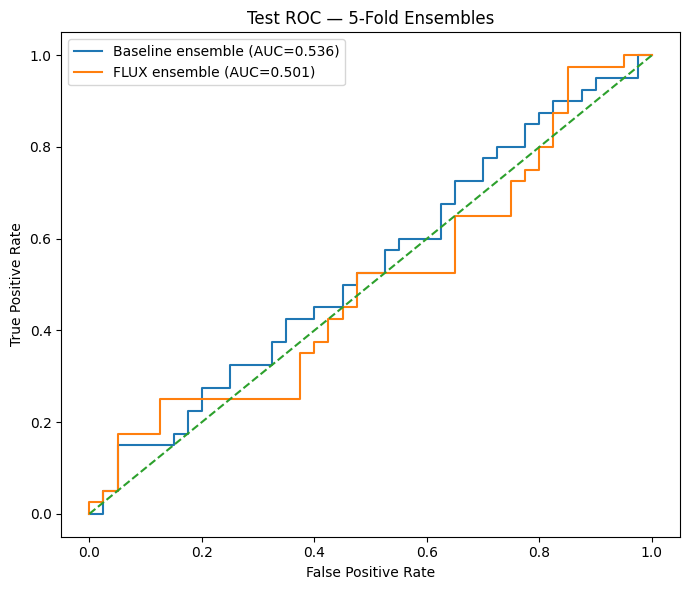

In [45]:
fpr_base, tpr_base, _ = roc_curve(base_test_true, base_test_prob[:, 1])
fpr_flux, tpr_flux, _ = roc_curve(flux_test_true, flux_test_prob[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, label=f"Baseline ensemble (AUC={base_test_metrics['roc_auc']:.3f})")
plt.plot(fpr_flux, tpr_flux, label=f"FLUX ensemble (AUC={flux_test_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC — 5-Fold Ensembles")
plt.legend()
plt.tight_layout()

plt.savefig(ENSEMBLE_DIR / "ensemble_test_roc_comparison.png", dpi=200)
plt.show()

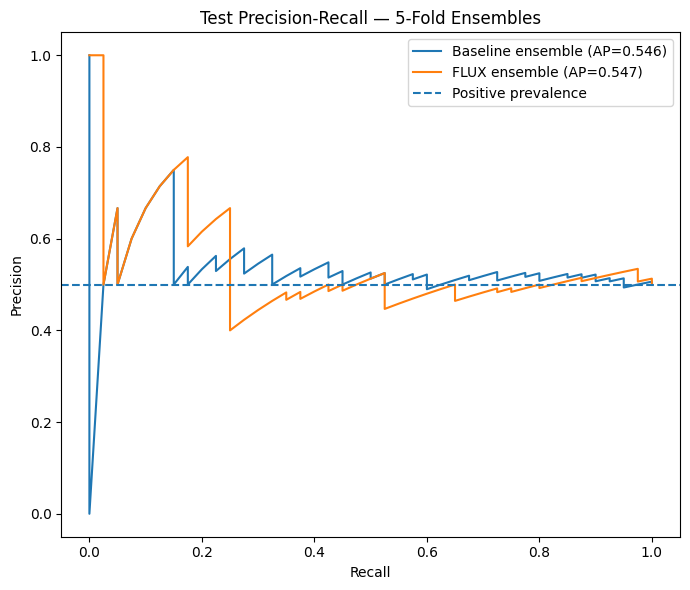

In [46]:
p_base, r_base, _ = precision_recall_curve(base_test_true, base_test_prob[:, 1])
p_flux, r_flux, _ = precision_recall_curve(flux_test_true, flux_test_prob[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(r_base, p_base, label=f"Baseline ensemble (AP={base_test_metrics['pr_auc']:.3f})")
plt.plot(r_flux, p_flux, label=f"FLUX ensemble (AP={flux_test_metrics['pr_auc']:.3f})")
plt.axhline(np.mean(base_test_true == 1), linestyle="--", label="Positive prevalence")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision-Recall — 5-Fold Ensembles")
plt.legend()
plt.tight_layout()

plt.savefig(ENSEMBLE_DIR / "ensemble_test_pr_comparison.png", dpi=200)
plt.show()

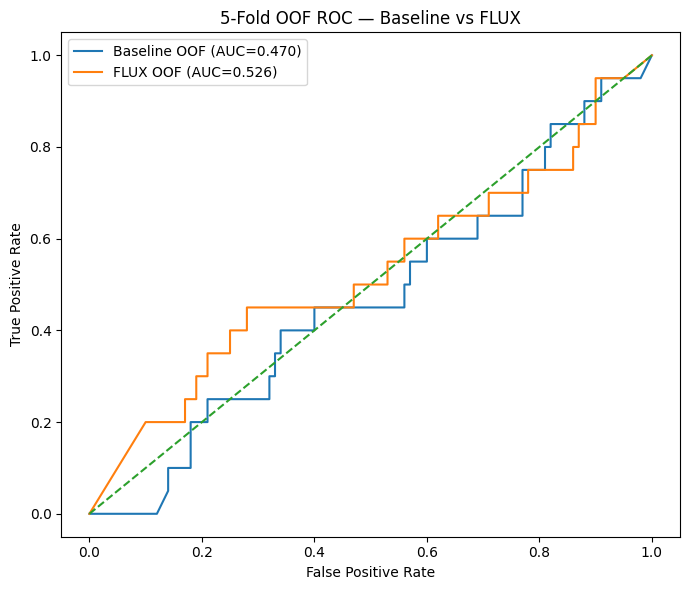

In [47]:
fpr_base, tpr_base, _ = roc_curve(cv_labels, baseline_oof_prob)
fpr_flux, tpr_flux, _ = roc_curve(cv_labels, flux_oof_prob)

auc_base = roc_auc_score(cv_labels, baseline_oof_prob)
auc_flux = roc_auc_score(cv_labels, flux_oof_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, label=f"Baseline OOF (AUC={auc_base:.3f})")
plt.plot(fpr_flux, tpr_flux, label=f"FLUX OOF (AUC={auc_flux:.3f})")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("5-Fold OOF ROC — Baseline vs FLUX")
plt.legend()
plt.tight_layout()

plt.savefig(OOF_DIR / "oof_roc_comparison.png", dpi=200)
plt.show()

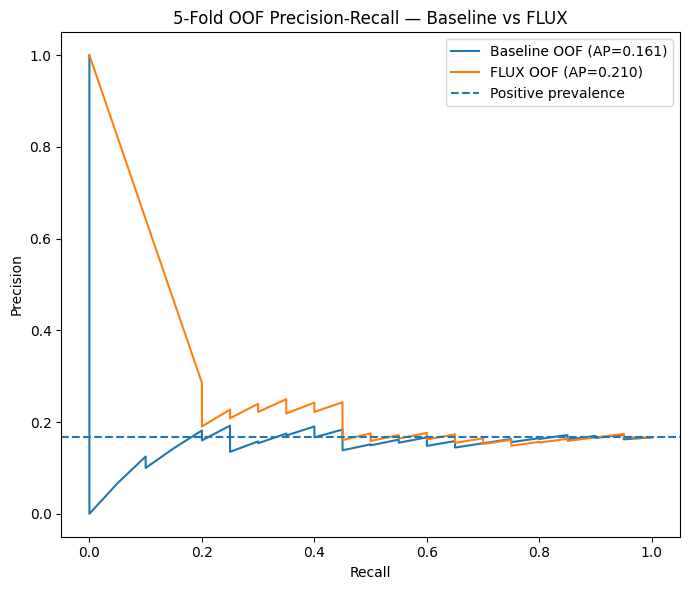

In [48]:
p_base, r_base, _ = precision_recall_curve(cv_labels, baseline_oof_prob)
p_flux, r_flux, _ = precision_recall_curve(cv_labels, flux_oof_prob)

ap_base = average_precision_score(cv_labels, baseline_oof_prob)
ap_flux = average_precision_score(cv_labels, flux_oof_prob)

plt.figure(figsize=(7, 6))
plt.plot(r_base, p_base, label=f"Baseline OOF (AP={ap_base:.3f})")
plt.plot(r_flux, p_flux, label=f"FLUX OOF (AP={ap_flux:.3f})")
plt.axhline(np.mean(cv_labels == 1), linestyle="--", label="Positive prevalence")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("5-Fold OOF Precision-Recall — Baseline vs FLUX")
plt.legend()
plt.tight_layout()

plt.savefig(OOF_DIR / "oof_pr_comparison.png", dpi=200)
plt.show()

In [49]:
from scipy.stats import binomtest

base_correct = base_test_pred == base_test_true
flux_correct = flux_test_pred == base_test_true

base_only = np.sum(base_correct & ~flux_correct)
flux_only = np.sum(~base_correct & flux_correct)

discordant = base_only + flux_only

print("Baseline correct / FLUX wrong:", base_only)
print("Baseline wrong / FLUX correct:", flux_only)

if discordant > 0:
    result = binomtest(base_only, n=discordant, p=0.5, alternative="two-sided")
    print("Exact McNemar p-value:", result.pvalue)
    
mcnemar_p_value = result.pvalue if discordant > 0 else 1.0

mcnemar_df = pd.DataFrame([{
    "comparison": "Baseline vs FLUX",
    "baseline_only_correct": int(base_only),
    "flux_only_correct": int(flux_only),
    "discordant": int(discordant),
    "mcnemar_p_value": mcnemar_p_value
}])

mcnemar_df.to_csv(
    ENSEMBLE_DIR / "mcnemar_baseline_vs_flux.csv",
    index=False
)

Baseline correct / FLUX wrong: 8
Baseline wrong / FLUX correct: 7
Exact McNemar p-value: 1.0


In [50]:
from scipy.stats import norm

def delong_components(y_true, y_score):
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)

    pos_scores = y_score[y_true == 1]  
    neg_scores = y_score[y_true == 0]  

    if len(pos_scores) < 2 or len(neg_scores) < 2:
        raise ValueError("DeLong test requires at least two samples from each class.")

    pairwise = (pos_scores[:, None] > neg_scores[None, :]).astype(float)
    pairwise += 0.5 * (pos_scores[:, None] == neg_scores[None, :])

    v10 = pairwise.mean(axis=1)
    v01 = pairwise.mean(axis=0)
    auc = v10.mean()

    return auc, v10, v01


def paired_delong_test(y_true, score_1, score_2):
    y_true = np.asarray(y_true)

    assert len(y_true) == len(score_1) == len(score_2)

    auc_1, v10_1, v01_1 = delong_components(y_true, score_1)
    auc_2, v10_2, v01_2 = delong_components(y_true, score_2)

    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)

    cov_pos = np.cov(np.vstack([v10_1, v10_2]), ddof=1)
    cov_neg = np.cov(np.vstack([v01_1, v01_2]), ddof=1)
    auc_cov = cov_pos / n_pos + cov_neg / n_neg

    auc_diff = auc_2 - auc_1
    var_diff = auc_cov[0, 0] + auc_cov[1, 1] - 2 * auc_cov[0, 1]
    var_diff = max(var_diff, 0.0) 

    if var_diff == 0:
        z = 0.0 if auc_diff == 0 else np.inf
        delong_p_value = 1.0 if auc_diff == 0 else 0.0
    else:
        z = auc_diff / np.sqrt(var_diff)
        delong_p_value = 2 * norm.sf(abs(z))

    return auc_1, auc_2, auc_diff, z, delong_p_value

assert np.array_equal(base_test_true, flux_test_true)

base_auc, flux_auc, auc_diff, z_stat, delong_p_value = paired_delong_test(
    base_test_true, base_test_prob[:, 1], flux_test_prob[:, 1]
)

print("\n===== DELONG TEST: BASELINE vs FLUX =====")
print(f"Baseline ROC-AUC: {base_auc:.4f}")
print(f"FLUX ROC-AUC:     {flux_auc:.4f}")
print(f"AUC difference (FLUX - Baseline): {auc_diff:+.4f}")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {delong_p_value:.6f}")
print("Result:", "significant ROC-AUC difference (p < 0.05)." if delong_p_value < 0.05 else "no significant ROC-AUC difference (p >= 0.05).")

delong_df = pd.DataFrame([{
    "comparison": "Baseline vs FLUX",
    "baseline_auc": base_auc,
    "flux_auc": flux_auc,
    "auc_difference": auc_diff,
    "z_statistic": z_stat,
    "delong_p_value": delong_p_value
}])
delong_df.to_csv(ENSEMBLE_DIR / "delong_baseline_vs_flux.csv", index=False)


===== DELONG TEST: BASELINE vs FLUX =====
Baseline ROC-AUC: 0.5356
FLUX ROC-AUC:     0.5006
AUC difference (FLUX - Baseline): -0.0350
z-statistic: -0.5931
p-value: 0.553094
Result: no significant ROC-AUC difference (p >= 0.05).


In [51]:
from scipy.stats import binomtest

cat_mask = base_test_true == 1

base_cat_pred = base_test_pred[cat_mask]
flux_cat_pred = flux_test_pred[cat_mask]

base_cat_correct = base_cat_pred == 1
flux_cat_correct = flux_cat_pred == 1

base_cat_recall = base_cat_correct.mean()
flux_cat_recall = flux_cat_correct.mean()
recall_diff = flux_cat_recall - base_cat_recall

base_only_cat = np.sum(base_cat_correct & ~flux_cat_correct)
flux_only_cat = np.sum(~base_cat_correct & flux_cat_correct)
discordant_cats = base_only_cat + flux_only_cat

cat_recall_p_value = binomtest(flux_only_cat, n=discordant_cats, p=0.5, alternative="two-sided").pvalue if discordant_cats > 0 else 1.0

print("\n===== CAT RECALL TEST: BASELINE vs FLUX =====")
print(f"Real cats in test set: {cat_mask.sum()}")
print(f"Baseline cat recall: {base_cat_recall:.4f}")
print(f"FLUX cat recall:     {flux_cat_recall:.4f}")
print(f"Recall difference (FLUX - Baseline): {recall_diff:+.4f}")
print(f"Baseline correct / FLUX wrong: {base_only_cat}")
print(f"Baseline wrong / FLUX correct: {flux_only_cat}")
print(f"p-value: {cat_recall_p_value:.6f}")
print("Result:", "significant cat-recall difference (p < 0.05)." if cat_recall_p_value < 0.05 else "no significant cat-recall difference (p >= 0.05).")

cat_recall_df = pd.DataFrame([{
    "comparison": "Baseline vs FLUX",
    "n_cats": int(cat_mask.sum()),
    "baseline_cat_recall": base_cat_recall,
    "flux_cat_recall": flux_cat_recall,
    "recall_difference": recall_diff,
    "baseline_only_correct": int(base_only_cat),
    "flux_only_correct": int(flux_only_cat),
    "discordant_cats": int(discordant_cats),
    "cat_recall_p_value": cat_recall_p_value
}])
cat_recall_df.to_csv(ENSEMBLE_DIR / "cat_recall_test_baseline_vs_flux.csv", index=False)


===== CAT RECALL TEST: BASELINE vs FLUX =====
Real cats in test set: 40
Baseline cat recall: 0.2250
FLUX cat recall:     0.0250
Recall difference (FLUX - Baseline): -0.2000
Baseline correct / FLUX wrong: 8
Baseline wrong / FLUX correct: 0
p-value: 0.007812
Result: significant cat-recall difference (p < 0.05).
